In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import json
import joblib

from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, precision_recall_curve, auc

# Generar un unico dataset

In [2]:
data_path = '/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP_Final/data/fraud/'

In [3]:
with open(os.path.join(data_path, 'train_fraud_labels.json'), 'r') as file:
    data = json.load(file)

In [4]:
df_target = pd.DataFrame.from_dict(data['target'], orient='index', columns=['Target']).reset_index()
cards_data = pd.read_parquet(os.path.join(data_path, 'cards_data.parquet'))
transactions_data = pd.read_parquet(os.path.join(data_path, 'transactions_data.parquet'))
users_data = pd.read_parquet(os.path.join(data_path, 'users_data.parquet'))

df_target = df_target.rename(columns={'index':'id'})
cards_data = cards_data.rename(columns={'id':'card_id'})
cards_data = cards_data.drop(['client_id'], axis=1)
users_data = users_data.rename(columns={'id':'client_id'})

In [5]:
cards_data['card_id'] = cards_data['card_id'].astype(str)
users_data['client_id'] = users_data['client_id'].astype(str)
transactions_data[['id', 'client_id', 'card_id']] = transactions_data[['id', 'client_id', 'card_id']].astype(str)

final_df = transactions_data.merge(df_target, on='id', how='left')
final_df = final_df.merge(cards_data, on='card_id', how='left')

final_df = final_df.merge(users_data, on='client_id', how='left')
final_df = final_df[~final_df['Target'].isna()]
final_df = final_df.drop(['card_id', 'merchant_id', 'zip','cvv','mcc','card_number' ], axis=1) # 'id', 'client_id'

In [6]:
final_df.to_parquet('final_fraud_df.parquet')

# Limpiar datos

In [7]:
#final_df = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP_Final/data/final_fraud_df.parquet')


final_df['date'] = pd.to_datetime(final_df['date'])

numeric_vars_adjust = ['amount', 'credit_limit', 'per_capita_income', 'yearly_income', 'total_debt']
for i in numeric_vars_adjust:
    final_df[i] = final_df[i].str.replace('$','').str.replace(',','').astype(float)
final_df['acct_open_date'] = pd.to_datetime(final_df['acct_open_date'], format='%m/%Y')
final_df['account_age'] = (final_df['date'] - final_df['acct_open_date']).dt.days / 30

final_df['expires'] = pd.to_datetime(final_df['expires'], format='%m/%Y')
final_df['time_to_expiry'] = (final_df['expires'] - final_df['date']).dt.days / 30

final_df['year'] = final_df['date'].dt.year
final_df['month'] = final_df['date'].dt.month
final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5,6])

vars_to_delete = ['date','address', 'birth_month', 'acct_open_date', 'expires', 'card_on_dark_web']

final_df.drop(vars_to_delete, axis=1, inplace=True)

final_df['Target'] = np.where(final_df['Target'] == 'Yes', 1, 0)
final_df['amount'] = final_df['amount'].round()
final_df['has_chip'] = np.where(final_df['has_chip'] == 'YES', 1, 0)
final_df['gender'] = np.where(final_df['gender'] == 'Male', 1, 0)

final_df['year'] = final_df['year'] - 2000
final_df['year_pin_last_changed'] = final_df['year_pin_last_changed'] - 2000

final_df['birth_year'] = final_df['birth_year'] - 1900
final_df['account_age'] = final_df['account_age'].round()
final_df['time_to_expiry'] = final_df['time_to_expiry'].round()

final_df['errors'] = final_df['errors'].fillna('no_errors')
final_df['merchant_state'] = final_df['merchant_state'].fillna('na_state')

dtypes_dict = {
    'Int32': ['credit_limit', 'per_capita_income', 'yearly_income', 'total_debt'],
    'Int16': ['credit_score','amount', 'account_age', 'time_to_expiry'],
    'Int8': ['year','month', 'is_weekend', 'Target', 'has_chip', 'num_cards_issued', 'year_pin_last_changed', 'current_age','retirement_age', 'birth_year', 'gender', 'num_credit_cards'],
    'category': ['card_brand', 'card_type', 'use_chip', 'errors', 'merchant_state']
}

for dtype, columns in dtypes_dict.items():
    for col in columns:
        print(f'Converting {col} to {dtype}')
        final_df[col] = final_df[col].astype(dtype)


test_years = [18, 19]
train_set = final_df[final_df['year'].isin(test_years) == False].copy()
test_set = final_df[final_df['year'].isin(test_years)].copy()
train_set.drop(['year', 'id', 'client_id'], axis=1, inplace=True)
test_set.drop('year', axis=1, inplace=True)
# train_set.to_parquet('data/train_set.parquet', index=False)
# test_set.to_parquet('data/test_set.parquet', index=False)

Converting credit_limit to Int32
Converting per_capita_income to Int32
Converting yearly_income to Int32
Converting total_debt to Int32
Converting credit_score to Int16
Converting amount to Int16
Converting account_age to Int16
Converting time_to_expiry to Int16
Converting year to Int8
Converting month to Int8
Converting is_weekend to Int8
Converting Target to Int8
Converting has_chip to Int8
Converting num_cards_issued to Int8
Converting year_pin_last_changed to Int8
Converting current_age to Int8
Converting retirement_age to Int8
Converting birth_year to Int8
Converting gender to Int8
Converting num_credit_cards to Int8
Converting card_brand to category
Converting card_type to category
Converting use_chip to category
Converting errors to category
Converting merchant_state to category


# Modelado

## Baseline Model - Logistic Regression

In [11]:
X_train = train_set.drop('Target', axis=1)
y_train = train_set['Target']

X_train = X_train.drop(['merchant_city'], axis=1)

X_train = pd.get_dummies(X_train, columns=['use_chip','errors', 'merchant_state','card_brand','card_type'], drop_first=True, dtype=int)

pipeline_sgd = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss='log_loss',
        penalty='l1',
        alpha=0.0001,
        class_weight='balanced',
        n_jobs=-1,
        early_stopping=True,
        random_state=444
    )
)

pipeline_sgd.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('sgdclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'log_loss'
,penalty,'l1'
,alpha,0.0001
,l1_ratio,0.15


# Comparar resultados

In [12]:
final_model_cb = CatBoostClassifier()
final_model_cb.load_model("fraud_model.cbm")

In [13]:
X_test = test_set.drop(['Target', 'id', 'client_id'], axis=1)
y_test = test_set['Target']

In [14]:
X_test_reg = X_test.drop(['merchant_city'], axis=1)

X_test_reg = pd.get_dummies(X_test_reg, columns=['use_chip','errors', 'merchant_state','card_brand','card_type'], drop_first=True, dtype=int)

In [15]:
preds_proba_reg = pipeline_sgd.predict_proba(X_test_reg)[:, 1]
preds_proba_cb = final_model_cb.predict_proba(X_test)[:, 1]

In [17]:
preds_75_reg = np.where(preds_proba_reg >= 0.97, 1, 0)

In [18]:
test_set['preds_cb'] = preds_75_reg

In [19]:
print("\nMatriz de Confusión (Test Set):")
print(pd.crosstab(index=y_test, columns=preds_75_reg).rename(columns={0:'Pred: No Fraude', 1:'Pred: Fraude'}))


Matriz de Confusión (Test Set):
col_0   Pred: No Fraude  Pred: Fraude
Target                               
0               1441612        267337
1                     9          2980


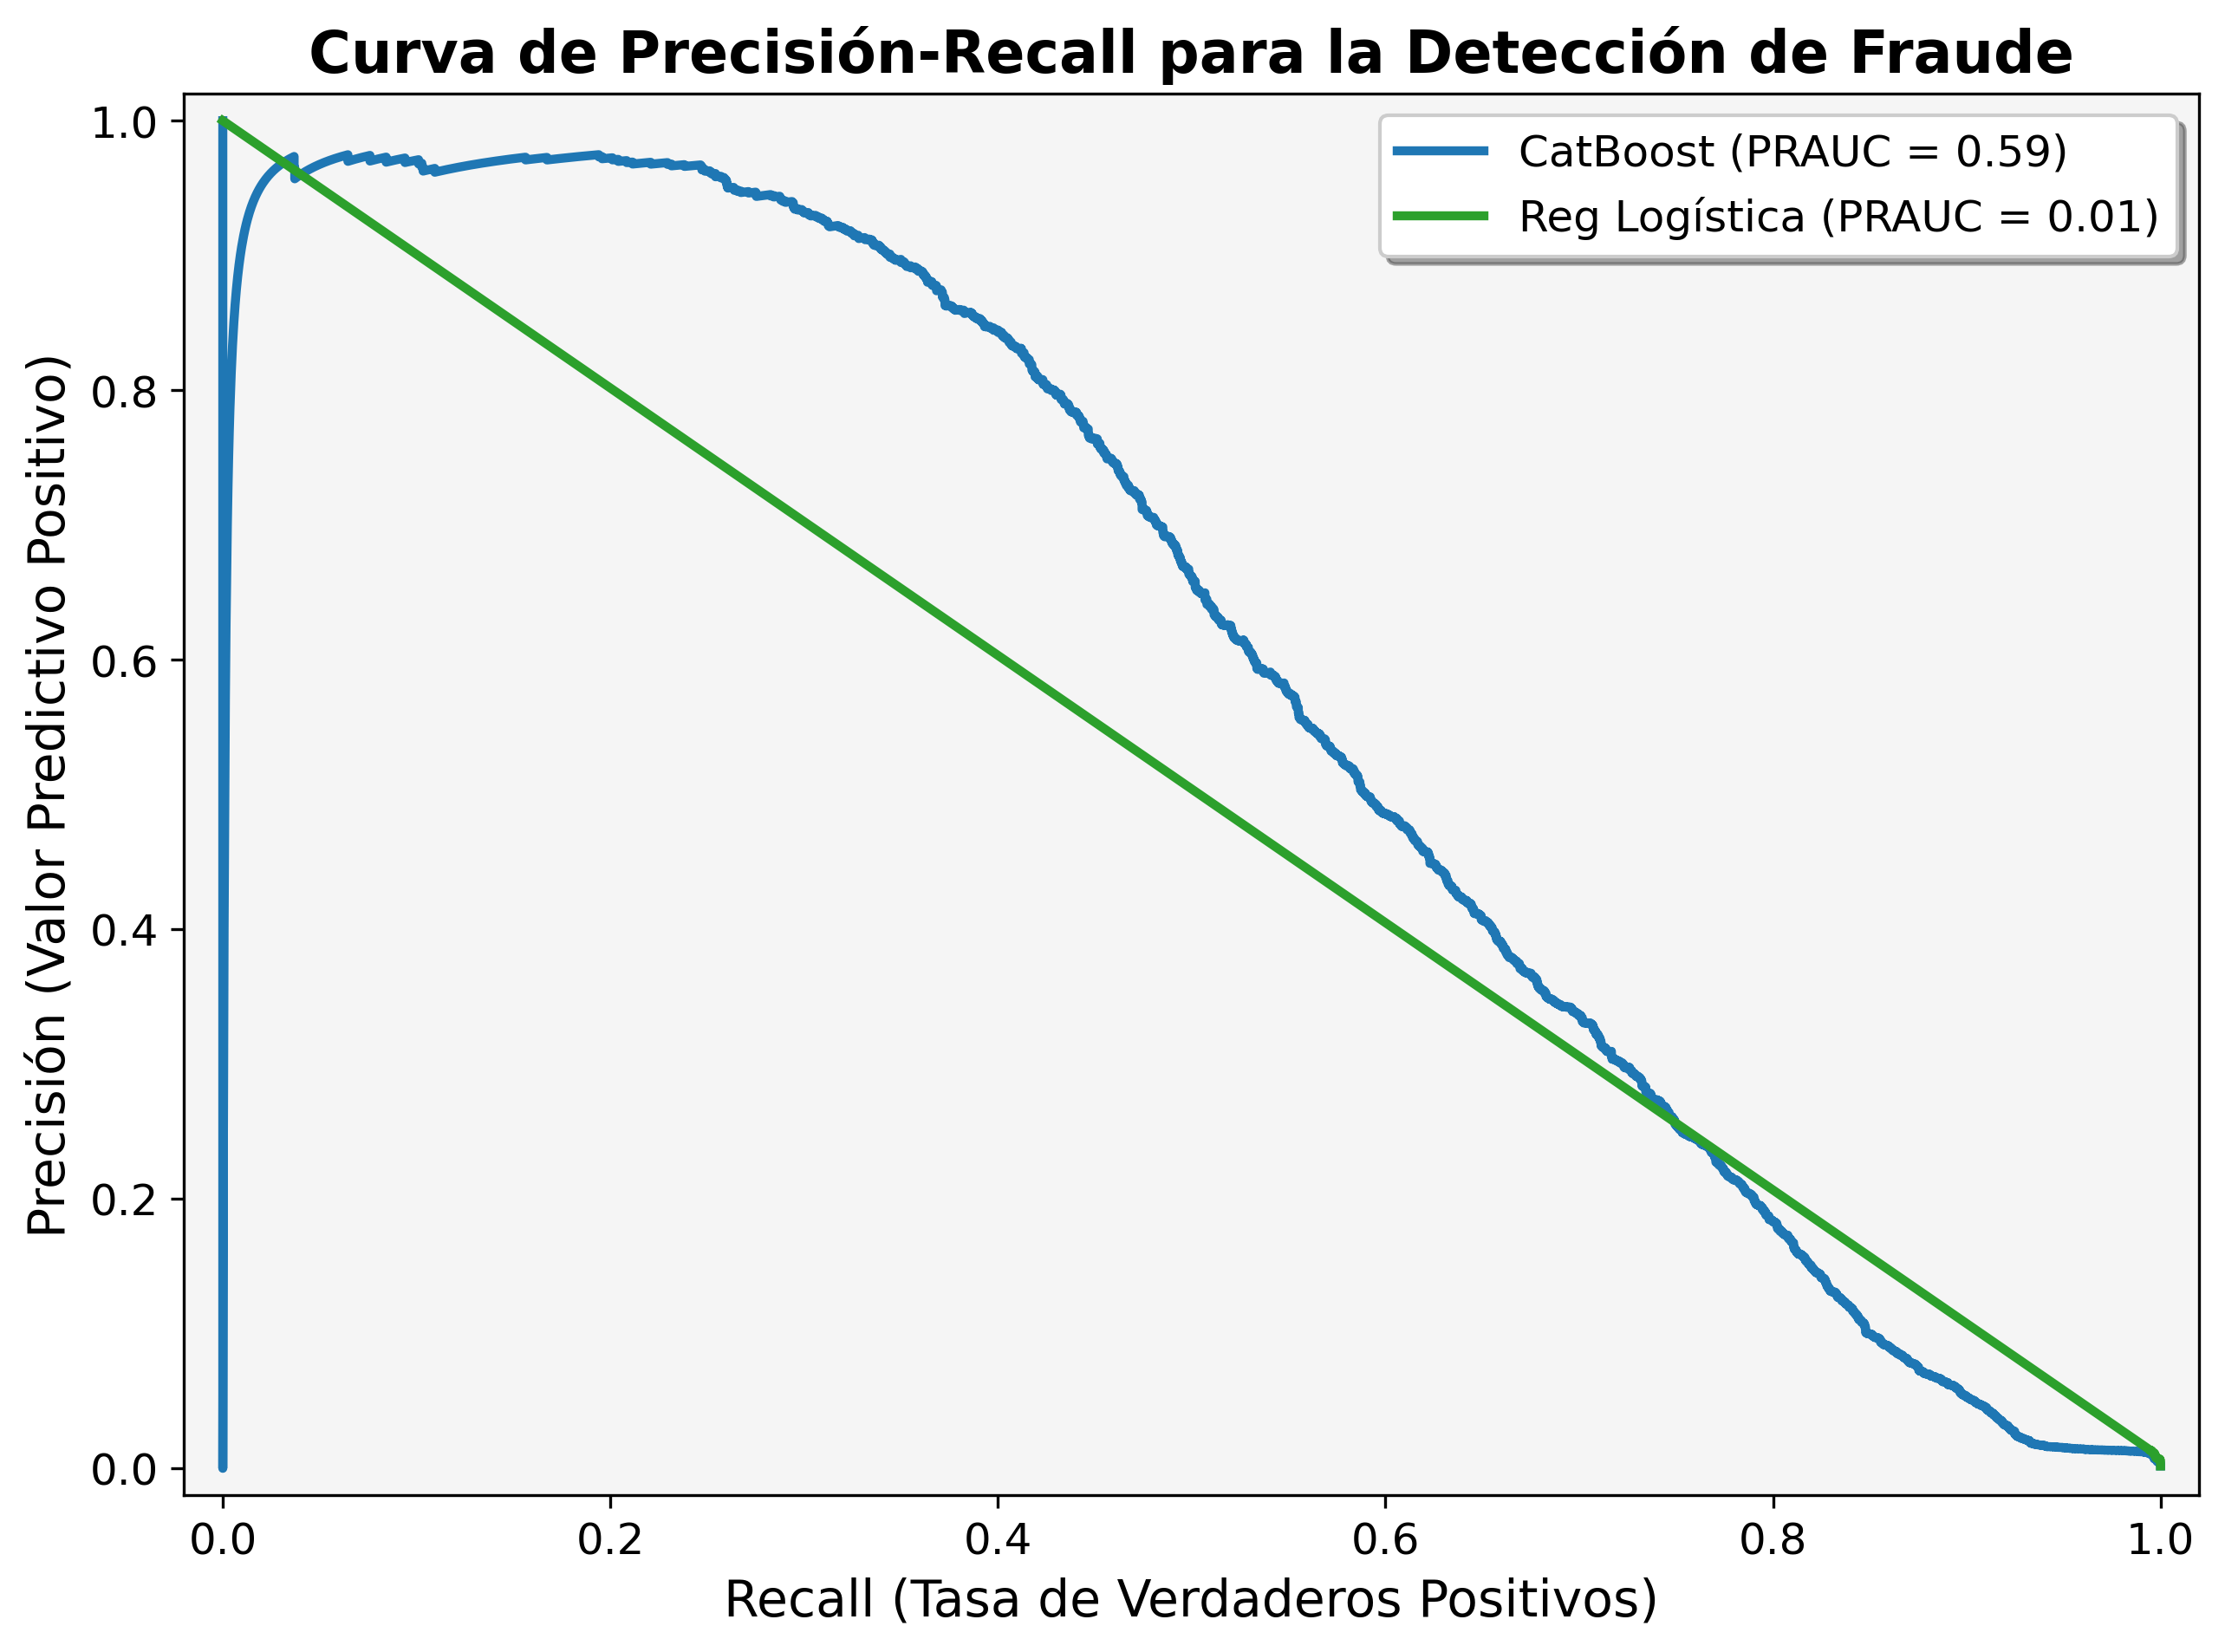

In [45]:


# --- 1. Calculate PR Curve components ---
precision_cb, recall_cb, _ = precision_recall_curve(y_test, preds_proba_cb)
precision_reg, recall_reg, _ = precision_recall_curve(y_test, preds_proba_reg)

ap_cb = average_precision_score(y_test, preds_proba_cb)
ap_reg = average_precision_score(y_test, preds_proba_reg)

plt.figure(figsize=(10, 7), dpi=300)
ax = plt.gca()

plt.plot(recall_cb, precision_cb, 
         label=f'CatBoost (PRAUC = {ap_cb:.2f})', 
         color='#1f77b4', # Matplotlib's default blue, looks good
         linewidth=2.5)

plt.plot(recall_reg, precision_reg, 
         label=f'Reg Logística (PRAUC = {ap_reg:.2f})', 
         color='#2ca02c', # Matplotlib's default green, looks good
         linewidth=2.5)

# Title
plt.title('Curva de Precisión-Recall para la Detección de Fraude', fontsize=16, weight='bold')
# Etiquetas de los ejes
plt.xlabel('Recall (Tasa de Verdaderos Positivos)', fontsize=14)
plt.ylabel('Precisión (Valor Predictivo Positivo)', fontsize=14)

# Leyenda
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

# Ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Axis Limits (optional, but good to ensure 0-1 range for PR curves)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

# Background color (optional, for a cleaner look)
ax.set_facecolor('whitesmoke')


In [ ]:
feature_importance = final_model_cb.get_feature_importance()
feature_names = X_test.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(importance_df)

# Valor economico

Responder a la pregunta: cuanto dinero representa el fraude detectado a nivel total y por cliente? Usar la muestra de test para hacer el calculo.

In [ ]:
test_set[(test_set['Target'] == 0)]['amount'].sum()

np.int64(72764489)

In [32]:
test_set[(test_set['Target'] == 1)]['amount'].sum()

np.int64(246711)

In [40]:
test_set[(test_set['preds_cb'] == 1) & (test_set['Target'] == 1)].groupby('client_id')['amount'].mean().mean()

np.float64(83.17347798595688)

In [10]:
test_set['amount'].mean()

np.float64(42.64827347719368)

In [9]:
test_set[(test_set['Target'] == 0)]['amount'].mean()

np.float64(42.57850234266792)